In [6]:
print("Google Colab is working")

Google Colab is working


In [7]:
from google.colab import files

uploaded = files.upload()

Saving European_Bank.csv to European_Bank.csv


In [8]:
import pandas as pd

In [9]:
df = pd.read_csv("European_Bank.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [10]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [12]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
df = df.drop(["CustomerId", "Surname"], axis=1)

print("Columns removed successfully.")
df.head()

Columns removed successfully.


,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 11)
Target Shape: (10000,)


In [16]:
X = pd.get_dummies(X, columns=["Geography", "Gender"], drop_first=True)

print("Categorical variables encoded successfully.")
X.head()

Categorical variables encoded successfully.


,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,2025,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,2025,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,2025,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,2025,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,2025,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8000, 12)
Testing Data: (2000, 12)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
lr = LogisticRegression(max_iter=1000)

In [21]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
y_pred = lr.predict(X_test)

In [23]:
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.808


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1540   53]
 [ 331   76]]


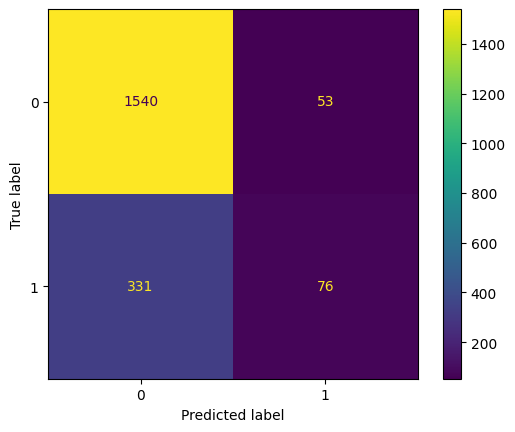

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

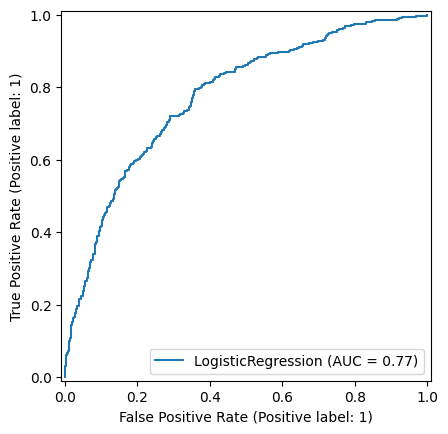

In [29]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    lr,
    X_test,
    y_test
)

plt.show()

In [30]:
from sklearn.metrics import roc_auc_score

probability = lr.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, probability)

print("ROC-AUC:", auc)

ROC-AUC: 0.7747778595236223


In [31]:
precision = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

print("Accuracy :", accuracy)

print("Precision :", precision["1"]["precision"])

print("Recall :", precision["1"]["recall"])

print("F1 Score :", precision["1"]["f1-score"])

print("ROC AUC :", auc)

Accuracy : 0.808
Precision : 0.5891472868217055
Recall : 0.18673218673218672
F1 Score : 0.2835820895522388
ROC AUC : 0.7747778595236223


In [32]:
from sklearn.tree import DecisionTreeClassifier

In [33]:
dt = DecisionTreeClassifier(random_state=42)

In [34]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [35]:
y_pred_dt = dt.predict(X_test)

In [36]:
print(y_pred_dt)

[0 0 0 ... 1 0 0]


In [37]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.779


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1593
           1       0.46      0.50      0.48       407

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.79      0.78      0.78      2000



In [39]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[1353  240]
 [ 202  205]]


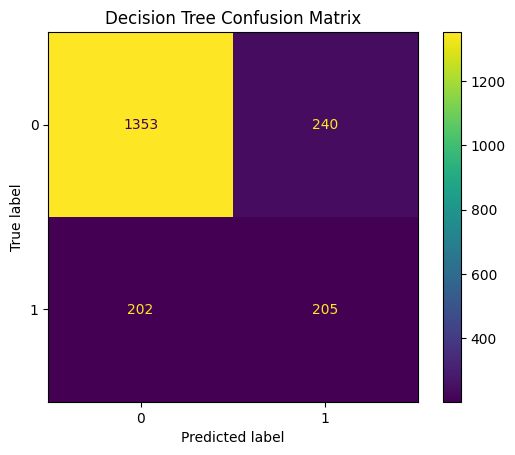

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)

plt.title("Decision Tree Confusion Matrix")
plt.show()

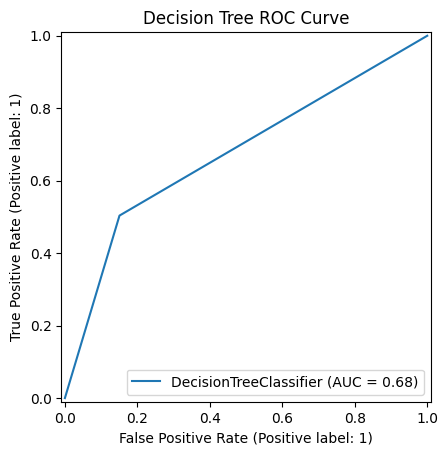

In [41]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    dt,
    X_test,
    y_test
)

plt.title("Decision Tree ROC Curve")
plt.show()

In [42]:
from sklearn.metrics import roc_auc_score

probability_dt = dt.predict_proba(X_test)[:,1]

auc_dt = roc_auc_score(y_test, probability_dt)

print("Decision Tree ROC-AUC:", auc_dt)

Decision Tree ROC-AUC: 0.6765131849877611


In [43]:
report_dt = classification_report(
    y_test,
    y_pred_dt,
    output_dict=True
)

print("Accuracy :", accuracy_dt)
print("Precision :", report_dt["1"]["precision"])
print("Recall :", report_dt["1"]["recall"])
print("F1 Score :", report_dt["1"]["f1-score"])
print("ROC AUC :", auc_dt)

Accuracy : 0.779
Precision : 0.4606741573033708
Recall : 0.5036855036855037
F1 Score : 0.4812206572769953
ROC AUC : 0.6765131849877611


In [44]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [47]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
y_pred_rf = rf.predict(X_test)

In [50]:
print(y_pred_rf)

[0 0 0 ... 1 0 0]


In [51]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.863


In [53]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[1540   53]
 [ 221  186]]


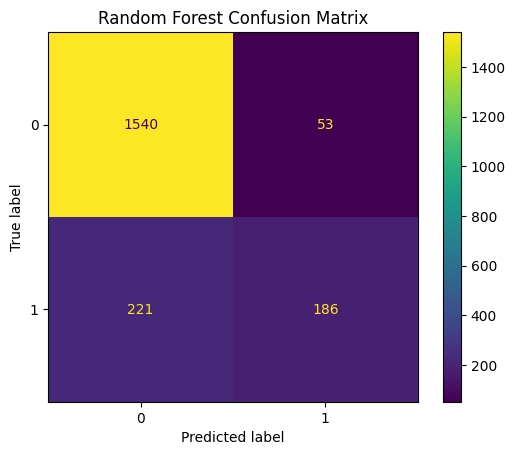

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

plt.title("Random Forest Confusion Matrix")
plt.show()

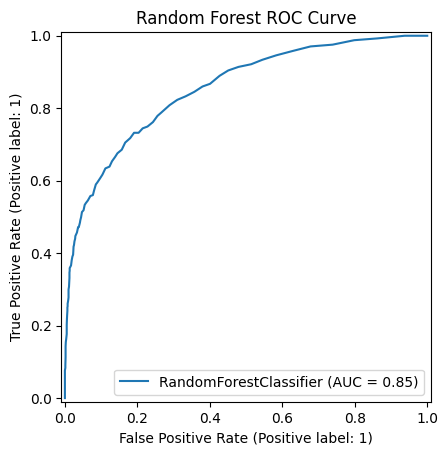

In [55]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Random Forest ROC Curve")
plt.show()

In [56]:
from sklearn.metrics import roc_auc_score

probability_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, probability_rf)

print("Random Forest ROC-AUC:", auc_rf)

Random Forest ROC-AUC: 0.8536579723020401


In [57]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Age,0.239564
8,EstimatedSalary,0.146649
1,CreditScore,0.143193
4,Balance,0.142788
5,NumOfProducts,0.128898
3,Tenure,0.081581
7,IsActiveMember,0.038760
9,Geography_Germany,0.028783
6,HasCrCard,0.018267
11,Gender_Male,0.018085


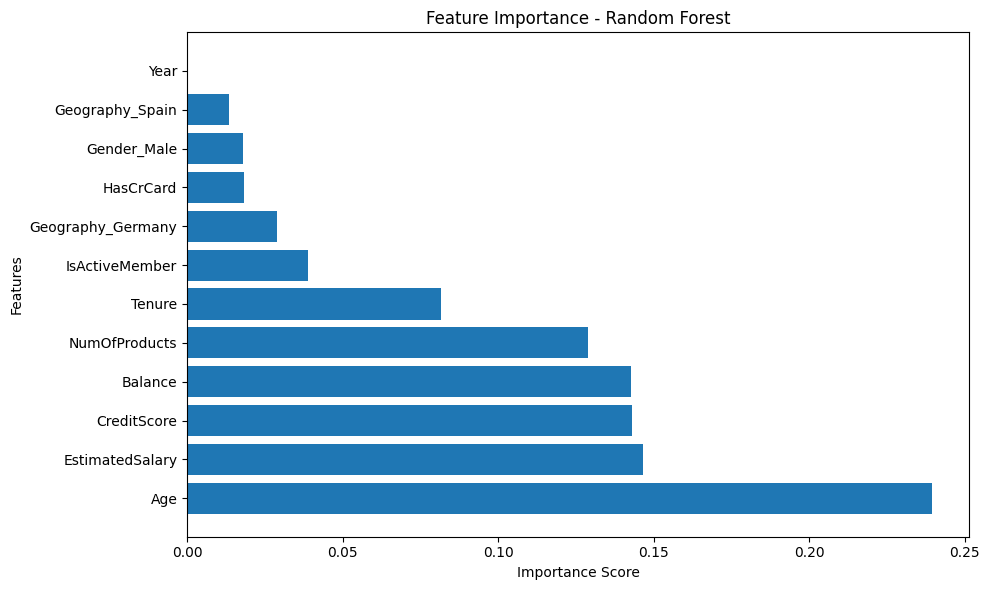

In [58]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [59]:
report_rf = classification_report(
    y_test,
    y_pred_rf,
    output_dict=True
)

print("Accuracy :", accuracy_rf)
print("Precision :", report_rf["1"]["precision"])
print("Recall :", report_rf["1"]["recall"])
print("F1 Score :", report_rf["1"]["f1-score"])
print("ROC AUC :", auc_rf)

Accuracy : 0.863
Precision : 0.7782426778242678
Recall : 0.457002457002457
F1 Score : 0.5758513931888545
ROC AUC : 0.8536579723020401


In [60]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.808
1,Decision Tree,0.779
2,Random Forest,0.863


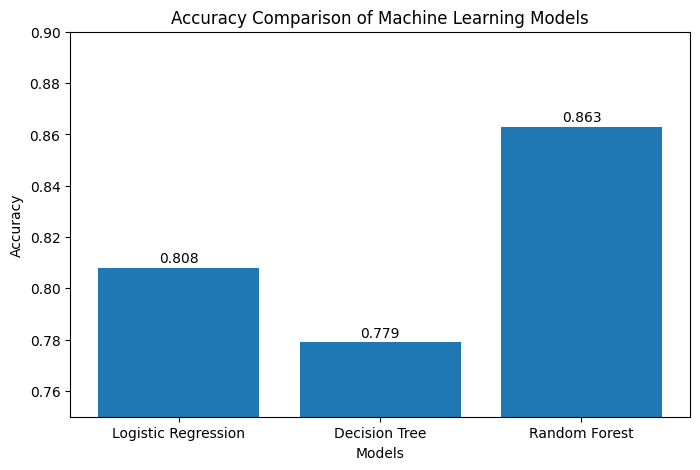

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.75,0.90)

for i, v in enumerate(comparison["Accuracy"]):
    plt.text(i, v+0.002, str(round(v,3)), ha="center")

plt.show()

In [62]:
from sklearn.ensemble import GradientBoostingClassifier

In [63]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

In [64]:
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [65]:
y_pred_gb = gb.predict(X_test)

In [66]:
print(y_pred_gb)

[0 0 0 ... 1 0 0]


In [67]:
from sklearn.metrics import accuracy_score

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 0.87


In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [69]:
from sklearn.metrics import confusion_matrix

cm_gb = confusion_matrix(y_test, y_pred_gb)

print(cm_gb)

[[1541   52]
 [ 208  199]]


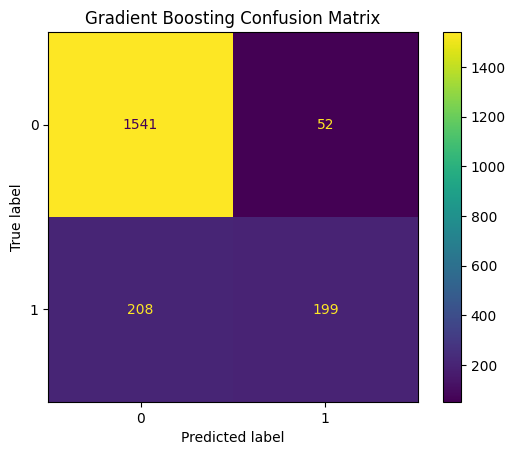

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb)

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

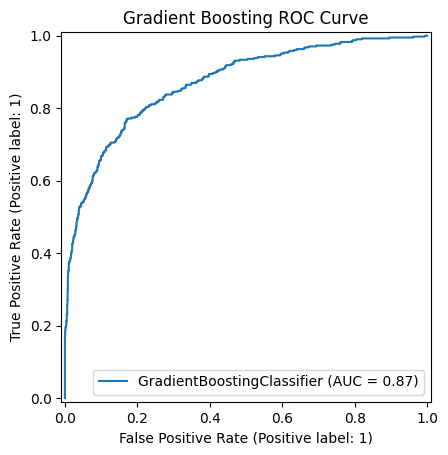

In [71]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    gb,
    X_test,
    y_test
)

plt.title("Gradient Boosting ROC Curve")
plt.show()

In [72]:
from sklearn.metrics import roc_auc_score

probability_gb = gb.predict_proba(X_test)[:,1]

auc_gb = roc_auc_score(y_test, probability_gb)

print("Gradient Boosting ROC-AUC:", auc_gb)

Gradient Boosting ROC-AUC: 0.8708307691358538


In [73]:
report_gb = classification_report(
    y_test,
    y_pred_gb,
    output_dict=True
)

print("Accuracy :", accuracy_gb)
print("Precision :", report_gb["1"]["precision"])
print("Recall :", report_gb["1"]["recall"])
print("F1 Score :", report_gb["1"]["f1-score"])
print("ROC AUC :", auc_gb)

Accuracy : 0.87
Precision : 0.7928286852589641
Recall : 0.48894348894348894
F1 Score : 0.6048632218844985
ROC AUC : 0.8708307691358538


In [74]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf,
        accuracy_gb
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
3,Gradient Boosting,0.870
2,Random Forest,0.863
0,Logistic Regression,0.808
1,Decision Tree,0.779


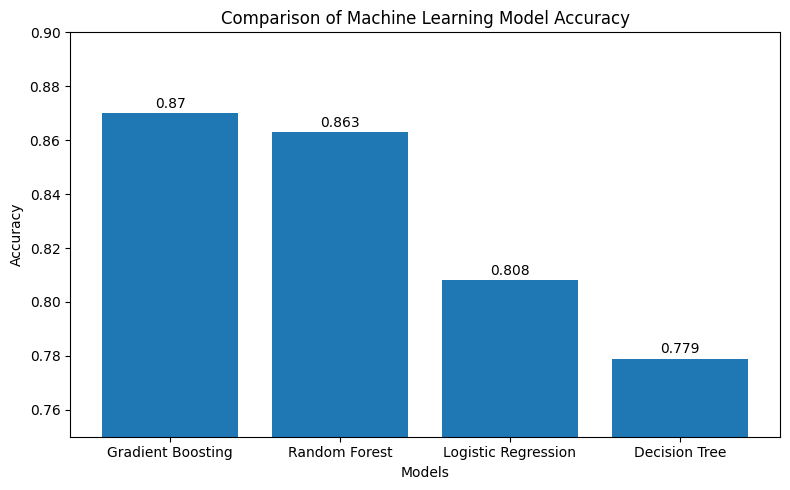

In [75]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Comparison of Machine Learning Model Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.75,0.90)

for i, v in enumerate(comparison["Accuracy"]):
    plt.text(i, v+0.002, str(round(v,3)), ha="center")

plt.tight_layout()
plt.show()

In [76]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Age,0.239564
8,EstimatedSalary,0.146649
1,CreditScore,0.143193
4,Balance,0.142788
5,NumOfProducts,0.128898
3,Tenure,0.081581
7,IsActiveMember,0.038760
9,Geography_Germany,0.028783
6,HasCrCard,0.018267
11,Gender_Male,0.018085


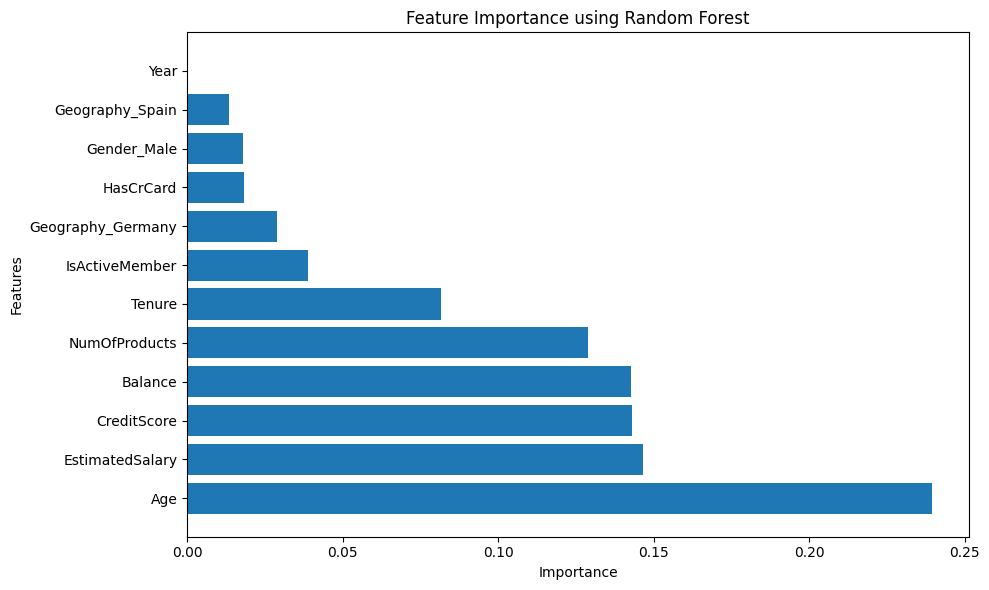

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance using Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [78]:
probability = rf.predict_proba(X_test)

risk = pd.DataFrame({
    "Probability": probability[:,1]
})

risk.head()

,Probability
0,0.08
1,0.06
2,0.08
3,0.01
4,0.07


In [79]:
def risk_level(x):

    if x >= 0.70:
        return "High Risk"

    elif x >= 0.30:
        return "Medium Risk"

    else:
        return "Low Risk"

risk["Risk Level"] = risk["Probability"].apply(risk_level)

risk.head(20)

,Probability,Risk Level
0,0.08,Low Risk
1,0.06,Low Risk
2,0.08,Low Risk
3,0.01,Low Risk
4,0.07,Low Risk
5,0.28,Low Risk
6,0.00,Low Risk
7,0.12,Low Risk
8,0.49,Medium Risk
9,0.14,Low Risk


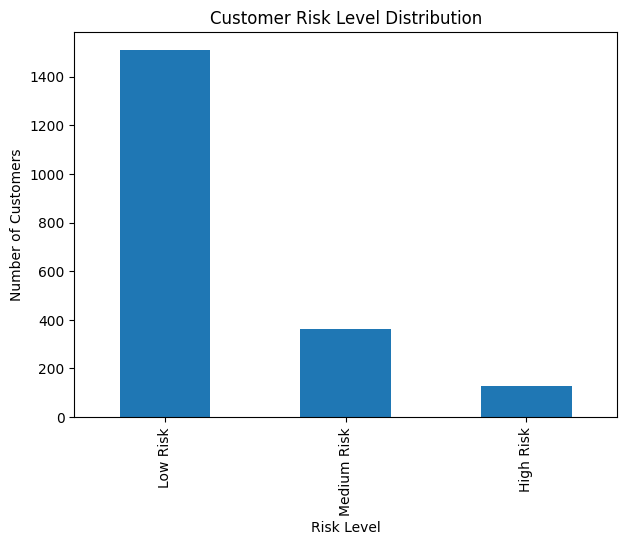

In [80]:
risk["Risk Level"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Customer Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.show()

In [83]:
import joblib

joblib.dump(
    rf,
    "Customer_Churn_Model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [84]:
feature_importance.to_csv(
    "FeatureImportance.csv",
    index=False
)

In [85]:
risk.to_csv(
    "CustomerRiskScore.csv",
    index=False
)

In [86]:
comparison.to_csv(
    "ModelComparison.csv",
    index=False
)

In [87]:
from google.colab import files

files.download("Customer_Churn_Model.pkl")

files.download("FeatureImportance.csv")

files.download("CustomerRiskScore.csv")

files.download("ModelComparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [104]:
import joblib

joblib.dump(scaler, "Customer_Churn_Scaler.pkl")

print("Scaler saved successfully")

Scaler saved successfully


In [105]:
from google.colab import files

files.download("Customer_Churn_Scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [88]:
from sklearn.ensemble import GradientBoostingClassifier

print("Gradient Boosting imported successfully.")

Gradient Boosting imported successfully.


In [89]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

print("Gradient Boosting model created.")

Gradient Boosting model created.


In [90]:
gb.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [91]:
y_pred_gb = gb.predict(X_test)

print("Predictions completed.")
print(y_pred_gb[:20])

Predictions completed.
[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]


In [92]:
from sklearn.metrics import accuracy_score

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)
print("Gradient Boosting Accuracy Percentage:", round(accuracy_gb * 100, 2), "%")

Gradient Boosting Accuracy: 0.87
Gradient Boosting Accuracy Percentage: 87.0 %


In [93]:
from sklearn.metrics import classification_report

print("Gradient Boosting Classification Report")
print(classification_report(
    y_test,
    y_pred_gb,
    target_names=["Retained", "Churned"]
))

Gradient Boosting Classification Report
              precision    recall  f1-score   support

    Retained       0.88      0.97      0.92      1593
     Churned       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [94]:
from sklearn.metrics import confusion_matrix

cm_gb = confusion_matrix(y_test, y_pred_gb)

print("Gradient Boosting Confusion Matrix:")
print(cm_gb)

Gradient Boosting Confusion Matrix:
[[1541   52]
 [ 208  199]]


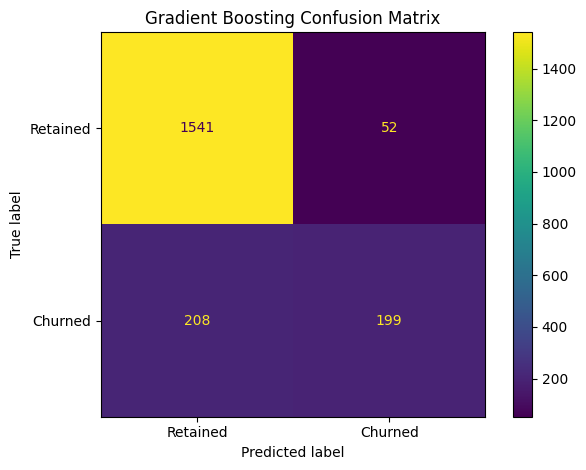

In [95]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=["Retained", "Churned"]
)

display.plot(values_format="d")

plt.title("Gradient Boosting Confusion Matrix")
plt.tight_layout()
plt.show()

In [96]:
probability_gb = gb.predict_proba(X_test)[:, 1]

print("First 20 predicted churn probabilities:")
print(probability_gb[:20])

First 20 predicted churn probabilities:
[0.02339717 0.07444868 0.03929758 0.04131615 0.09549491 0.18279378
 0.05151217 0.24371312 0.53455836 0.06160511 0.68049299 0.32860427
 0.02392185 0.04269323 0.11880821 0.01496412 0.05556333 0.13269758
 0.85849033 0.40725817]


In [97]:
from sklearn.metrics import roc_auc_score

auc_gb = roc_auc_score(y_test, probability_gb)

print("Gradient Boosting ROC-AUC:", round(auc_gb, 4))

Gradient Boosting ROC-AUC: 0.8708


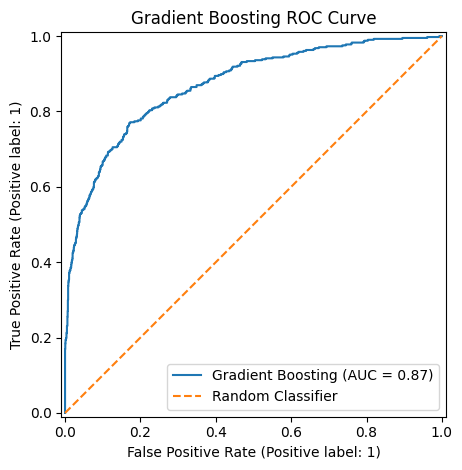

In [98]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    probability_gb,
    name="Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Gradient Boosting ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
report_gb = classification_report(
    y_test,
    y_pred_gb,
    output_dict=True
)

precision_gb = report_gb["1"]["precision"]
recall_gb = report_gb["1"]["recall"]
f1_gb = report_gb["1"]["f1-score"]

print("Gradient Boosting Performance Summary")
print("-------------------------------------")
print("Accuracy :", round(accuracy_gb, 4))
print("Precision:", round(precision_gb, 4))
print("Recall   :", round(recall_gb, 4))
print("F1 Score :", round(f1_gb, 4))
print("ROC-AUC  :", round(auc_gb, 4))

Gradient Boosting Performance Summary
-------------------------------------
Accuracy : 0.87
Precision: 0.7928
Recall   : 0.4889
F1 Score : 0.6049
ROC-AUC  : 0.8708


In [100]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf,
        accuracy_gb
    ]
})

comparison["Accuracy Percentage"] = (
    comparison["Accuracy"] * 100
).round(2)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Accuracy Percentage
0,Gradient Boosting,0.870,87.0
1,Random Forest,0.863,86.3
2,Logistic Regression,0.808,80.8
3,Decision Tree,0.779,77.9


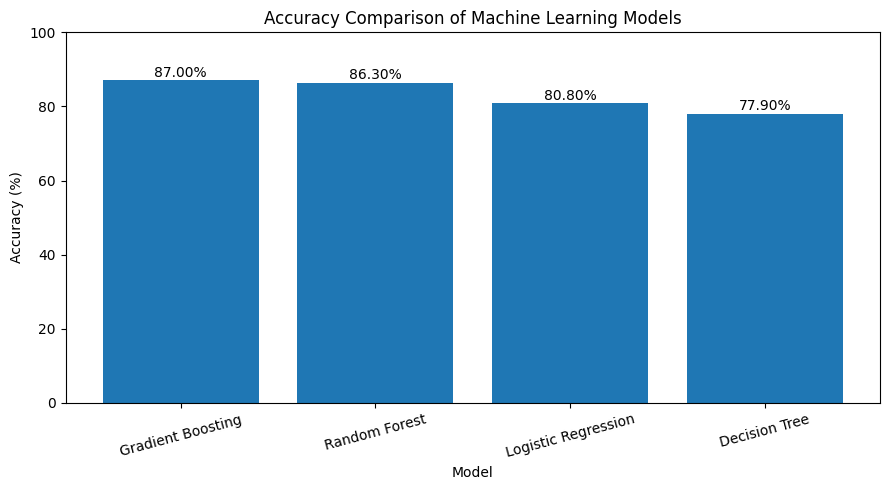

In [101]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy Percentage"]
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)

for index, value in enumerate(
    comparison["Accuracy Percentage"]
):
    plt.text(
        index,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [102]:
import joblib

joblib.dump(rf, "Customer_Churn_Model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [103]:
from google.colab import files

files.download("Customer_Churn_Model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>